# Module 20: Week 9 BBO Optimization

## Scaling, Emergence, and Directional Exploitation

With 18 data points and **5 weeks remaining** (including this one), we shift to a strategy that:
1. **Exploits improvement trajectories** — for F1, F4, F6 where we see clear directional gains
2. **Fixes numerical issues** — robust Thompson Sampling with diagonal approximation (SVD fix from Week 8)
3. **Boundary-aware search** — pinning F5's critical dimensions near 1.0
4. **Broader exploration for stagnant functions** — F2 needs a fundamentally different approach
5. **LOO-CV model validation** — with 18 points we can now validate GP kernel choices

### Week 8 Results Summary
| Function | Week 8 Value | Previous Best | Result |
|----------|-------------|---------------|--------|
| F1 | **1.7727** | 1.626 | **NEW BEST** (+9.0%) |
| F2 | 0.5836 | 0.667 | Regression |
| F3 | -0.0167 | -0.0145 | Regression |
| F4 | **0.6287** | 0.600 | **NEW BEST** (+4.8%) |
| F5 | 1415.4 | 1618.5 | Regression |
| F6 | **-0.5864** | -0.681 | **NEW BEST** (+13.9%) |
| F7 | **2.4329** | 2.403 | **NEW BEST** (+1.2%) |
| F8 | **9.928** | 9.915 | **NEW BEST** (+0.1%) |

**5 new bests out of 8** — best week so far!

In [47]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm
from scipy.stats.qmc import Sobol
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

import sys
sys.path.append('..')
from src.utils import load_data, save_submission

print("Week 9 (Module 20) — Directional Exploitation & Robust BO")

Week 9 (Module 20) — Directional Exploitation & Robust BO


## 1. Load All Data and Compute Improvement Trajectories

In [48]:
def fmt(arr, d=6):
    return [round(float(x), d) for x in arr]

# Load all data
best_values = {}
best_locations = {}
all_data = {}
dims = {}

for func_id in range(1, 9):
    df = load_data(func_id)
    all_data[func_id] = df
    dim = len([c for c in df.columns if c.startswith('x')])
    dims[func_id] = dim
    
    best_idx = df['y'].idxmax()
    best_y = df.loc[best_idx, 'y']
    best_x = df.loc[best_idx, [f'x{i}' for i in range(dim)]].values
    
    best_values[func_id] = best_y
    best_locations[func_id] = best_x
    
    print(f"F{func_id} ({dim}D): Best = {best_y:.6f} at {fmt(best_x, 4)}")
    print(f"   Points: {len(df)}, Source: {df.loc[best_idx, 'source']}")

F1 (2D): Best = 1.772710 at [0.6307, 0.6218]
   Points: 18, Source: week_8_submission
F2 (2D): Best = 0.666983 at [0.7026, 0.9266]
   Points: 18, Source: week_4_submission
F3 (3D): Best = -0.014466 at [0.5198, 0.6294, 0.3797]
   Points: 23, Source: week_7_submission
F4 (4D): Best = 0.628683 at [0.4234, 0.3779, 0.4125, 0.4247]
   Points: 38, Source: week_8_submission
F5 (4D): Best = 1618.493116 at [0.3627, 0.2734, 0.9961, 0.9975]
   Points: 28, Source: week_1_submission
F6 (5D): Best = -0.586391 at [0.6902, 0.1258, 0.7578, 0.7367, 0.051]
   Points: 28, Source: week_8_submission
F7 (6D): Best = 2.432916 at [0.01, 0.1076, 0.5812, 0.206, 0.3653, 0.7405]
   Points: 38, Source: week_8_submission
F8 (8D): Best = 9.928049 at [0.0259, 0.0952, 0.1534, 0.0495, 0.871, 0.3337, 0.1697, 0.223]
   Points: 48, Source: week_8_submission


In [49]:
# Compute improvement trajectories for functions with recent improvement
# Compare the two best submissions to extract a direction of improvement

def compute_improvement_direction(df, dim):
    """Compute direction of improvement from top submissions."""
    x_cols = [f'x{i}' for i in range(dim)]
    
    # Get top submissions sorted by y value
    top = df.nlargest(3, 'y')
    
    if len(top) < 2:
        return None
    
    x_best = top.iloc[0][x_cols].values.astype(float)
    x_second = top.iloc[1][x_cols].values.astype(float)
    
    direction = x_best - x_second
    norm = np.linalg.norm(direction)
    
    if norm < 1e-10:
        return None
    
    return direction / norm, norm

print("Improvement trajectories:")
print("=" * 60)
trajectories = {}
for func_id in range(1, 9):
    result = compute_improvement_direction(all_data[func_id], dims[func_id])
    if result is not None:
        direction, magnitude = result
        trajectories[func_id] = direction
        print(f"F{func_id}: direction = {fmt(direction, 4)}, step size = {magnitude:.4f}")
    else:
        print(f"F{func_id}: No clear improvement direction")

Improvement trajectories:
F1: direction = [-0.2698, -0.9629], step size = 0.0143
F2: direction = [0.9133, -0.4072], step size = 0.0000
F3: direction = [-0.5831, -0.5559, -0.5925], step size = 0.0335
F4: direction = [0.2559, -0.5006, 0.7496, 0.3491], step size = 0.0736
F5: No clear improvement direction
F6: direction = [-0.6529, -0.7036, 0.1625, 0.2204, -0.0609], step size = 0.0279
F7: direction = [0.0, -0.5602, 0.4924, -0.5359, -0.3898, -0.0683], step size = 0.0871
F8: direction = [0.0238, 0.0061, -0.2901, 0.4118, -0.4913, 0.4315, 0.0964, 0.5557], step size = 0.0333


## 2. Improved Multi-Kernel GP Ensemble

Key fixes from Week 8:
- **Robust Thompson Sampling** with jitter to prevent SVD convergence failures
- **LOO-CV** for model validation alongside log marginal likelihood

In [50]:
class RobustMultiKernelGP:
    """Multi-kernel GP ensemble with robust Thompson Sampling and LOO-CV."""
    
    def __init__(self, dim):
        self.dim = dim
        self.gps = []
        self.weights = []
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.loo_scores = []
        
    def fit(self, X, y):
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
        
        nus = [0.5, 1.5, 2.5]
        self.gps = []
        log_marginal_likelihoods = []
        self.loo_scores = []
        
        for nu in nus:
            kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
                length_scale=np.ones(self.dim),
                length_scale_bounds=(1e-2, 1e2),
                nu=nu
            ) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
            
            gp = GaussianProcessRegressor(
                kernel=kernel,
                n_restarts_optimizer=10,
                normalize_y=False,
                alpha=1e-6
            )
            gp.fit(X_scaled, y_scaled)
            self.gps.append(gp)
            log_marginal_likelihoods.append(gp.log_marginal_likelihood_value_)
            
            # Fast LOO-CV: reuse fitted kernel (n_restarts_optimizer=0)
            loo = LeaveOneOut()
            loo_errors = []
            for train_idx, test_idx in loo.split(X_scaled):
                gp_loo = GaussianProcessRegressor(
                    kernel=gp.kernel_, n_restarts_optimizer=0,
                    normalize_y=False, alpha=1e-6
                )
                gp_loo.fit(X_scaled[train_idx], y_scaled[train_idx])
                pred = gp_loo.predict(X_scaled[test_idx])
                loo_errors.append((pred[0] - y_scaled[test_idx[0]])**2)
            self.loo_scores.append(np.mean(loo_errors))
        
        # Combine LML and LOO-CV for weights
        lml = np.array(log_marginal_likelihoods)
        lml = lml - np.max(lml)
        lml_weights = np.exp(lml)
        lml_weights = lml_weights / np.sum(lml_weights)
        
        # LOO weights (inverse error, lower = better)
        loo_arr = np.array(self.loo_scores)
        loo_inv = 1.0 / (loo_arr + 1e-10)
        loo_weights = loo_inv / np.sum(loo_inv)
        
        # Average both weight sources
        self.weights = 0.6 * lml_weights + 0.4 * loo_weights
        self.weights = self.weights / np.sum(self.weights)
        
        print(f"  LML weights:  v=0.5: {lml_weights[0]:.3f}, v=1.5: {lml_weights[1]:.3f}, v=2.5: {lml_weights[2]:.3f}")
        print(f"  LOO weights:  v=0.5: {loo_weights[0]:.3f}, v=1.5: {loo_weights[1]:.3f}, v=2.5: {loo_weights[2]:.3f}")
        print(f"  Final weights: v=0.5: {self.weights[0]:.3f}, v=1.5: {self.weights[1]:.3f}, v=2.5: {self.weights[2]:.3f}")
        print(f"  LOO-CV RMSE:  v=0.5: {np.sqrt(self.loo_scores[0]):.4f}, v=1.5: {np.sqrt(self.loo_scores[1]):.4f}, v=2.5: {np.sqrt(self.loo_scores[2]):.4f}")
        
    def predict(self, X, return_std=True):
        X_scaled = self.scaler_X.transform(X)
        
        mu_ensemble = np.zeros(len(X))
        var_ensemble = np.zeros(len(X))
        
        for gp, w in zip(self.gps, self.weights):
            mu, sigma = gp.predict(X_scaled, return_std=True)
            mu_ensemble += w * mu
            var_ensemble += w * (sigma**2 + mu**2)
        
        var_ensemble -= mu_ensemble**2
        sigma_ensemble = np.sqrt(np.maximum(var_ensemble, 1e-10))
        
        mu_orig = self.scaler_y.inverse_transform(mu_ensemble.reshape(-1, 1)).ravel()
        sigma_orig = sigma_ensemble * self.scaler_y.scale_[0]
        
        if return_std:
            return mu_orig, sigma_orig
        return mu_orig
    
    def sample_posterior_diagonal(self, X, n_samples=100):
        """Fast Thompson Sampling using diagonal (independent) approximation.
        
        Instead of computing the full N x N covariance matrix (which is O(N^2) memory
        and O(N^3) for Cholesky), we sample independently at each point using
        mu +/- sigma. This is a good approximation for candidate ranking.
        """
        mu, sigma = self.predict(X, return_std=True)
        # Independent normal samples at each candidate point
        samples = mu[:, np.newaxis] + sigma[:, np.newaxis] * np.random.randn(len(X), n_samples)
        return samples

## 3. Acquisition Functions

In [51]:
def ucb(mu, sigma, kappa=2.0):
    """Upper Confidence Bound."""
    return mu + kappa * sigma

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """Expected Improvement."""
    improvement = mu - y_best - xi
    Z = improvement / (sigma + 1e-10)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma > 1e-10, ei, 0.0)

def probability_of_improvement(mu, sigma, y_best, xi=0.001):
    """Probability of Improvement — good for exploitation."""
    Z = (mu - y_best - xi) / (sigma + 1e-10)
    return norm.cdf(Z)

def thompson_sampling_idx(gp_ensemble, X_candidates, n_samples=100):
    """Thompson Sampling via fast diagonal approximation.
    
    Uses independent per-point sampling (no full covariance matrix needed).
    This is O(N) instead of O(N^3) and works well for candidate ranking.
    """
    samples = gp_ensemble.sample_posterior_diagonal(X_candidates, n_samples=n_samples)
    
    # For each posterior sample, find the best candidate
    best_indices = np.argmax(samples, axis=0)
    
    from collections import Counter
    counter = Counter(best_indices.tolist())
    return counter.most_common(1)[0][0]

## 4. Directional Trust Region

New for Week 9: when we have an improvement trajectory, bias candidate generation
in the direction of improvement while still exploring laterally.

In [52]:
class DirectionalTrustRegion:
    """Trust region with optional directional bias for exploitation."""
    
    def __init__(self, dim, center, radius=0.05, direction=None, direction_weight=0.3):
        self.dim = dim
        self.center = np.array(center, dtype=float)
        self.radius = radius
        self.direction = np.array(direction, dtype=float) if direction is not None else None
        self.direction_weight = direction_weight
    
    def generate_candidates(self, n_candidates=20000):
        """Generate candidates with optional directional bias."""
        candidates = []
        
        # Use Sobol sequence for better space coverage
        sobol = Sobol(d=self.dim, scramble=True, seed=42)
        sobol_samples = sobol.random(n_candidates)  # [0,1]^d
        
        # Map to trust region
        base_candidates = self.center + (sobol_samples - 0.5) * 2 * self.radius
        
        if self.direction is not None:
            # Add directionally-biased candidates
            n_directional = int(n_candidates * self.direction_weight)
            n_uniform = n_candidates - n_directional
            
            # Directional candidates: sample along improvement direction
            # with smaller lateral perturbation
            dir_candidates = []
            for _ in range(n_directional):
                # Step along direction (0 to 1.5x radius)
                step = np.random.uniform(0, 1.5 * self.radius)
                lateral = np.random.normal(0, self.radius * 0.3, self.dim)
                # Project out the direction component from lateral noise
                lateral -= np.dot(lateral, self.direction) * self.direction
                candidate = self.center + step * self.direction + lateral
                dir_candidates.append(candidate)
            
            dir_candidates = np.array(dir_candidates)
            all_candidates = np.vstack([base_candidates[:n_uniform], dir_candidates])
        else:
            all_candidates = base_candidates
        
        # Clip to actual domain [0, 1] — no artificial margin
        all_candidates = np.clip(all_candidates, 0.0, 1.0)
        return all_candidates


class BoundaryAwareTrustRegion:
    """Trust region that pins specified dimensions near boundary values."""
    
    def __init__(self, dim, center, radius=0.05,
                 pinned_dims=None, pinned_range=(0.99, 0.999)):
        self.dim = dim
        self.center = np.array(center, dtype=float)
        self.radius = radius
        self.pinned_dims = pinned_dims or []
        self.pinned_range = pinned_range
    
    def generate_candidates(self, n_candidates=20000):
        sobol = Sobol(d=self.dim, scramble=True, seed=42)
        sobol_samples = sobol.random(n_candidates)
        
        candidates = self.center + (sobol_samples - 0.5) * 2 * self.radius
        
        # Clip to actual domain [0, 1] first
        candidates = np.clip(candidates, 0.0, 1.0)
        
        # Then pin specified dimensions to boundary range (AFTER clipping)
        for d in self.pinned_dims:
            candidates[:, d] = np.random.uniform(
                self.pinned_range[0], self.pinned_range[1], n_candidates
            )
        
        return candidates

## 5. Main Optimization Engine

In [53]:
def optimize_function(func_id, strategy='exploit', custom_radius=None,
                      direction=None, pinned_dims=None, pinned_range=None,
                      kappa=2.0, n_candidates=20000,
                      selection='auto', center_override=None):
    """
    Generate next query for a function.
    
    Strategies:
    - 'exploit': Tight trust region around best (radius 0.02)
    - 'directional': Directional exploitation with improvement vector
    - 'turbo': Moderate trust region (radius 0.05)
    - 'explore': Broader search (radius 0.15)
    - 'boundary': Boundary-aware search with pinned dimensions
    
    Selection methods:
    - 'auto': PI for exploit/boundary, EI for directional, UCB for explore, EI+UCB for turbo
    - 'pi': Probability of Improvement (conservative, best for exploitation)
    - 'ei': Expected Improvement (balanced)
    - 'mean': Pure GP mean maximization (most conservative)
    - 'ucb': Upper Confidence Bound (exploratory)
    - 'ei+ucb': Combined metric
    """
    df = all_data[func_id]
    dim = dims[func_id]
    
    X = df[[f'x{i}' for i in range(dim)]].values
    y = df['y'].values
    
    y_best = np.max(y)
    best_idx = np.argmax(y)
    x_best = X[best_idx]
    
    # Allow overriding the trust region center
    center = center_override if center_override is not None else x_best
    
    print(f"\n{'='*60}")
    print(f"Function {func_id} ({dim}D) — Strategy: {strategy}, Selection: {selection}")
    print(f"Best: {y_best:.6f} at {fmt(x_best, 4)}")
    if center_override is not None:
        print(f"Center override: {fmt(center, 4)}")
    print(f"Data points: {len(df)}")
    print(f"{'='*60}")
    
    # Build ensemble model
    ensemble = RobustMultiKernelGP(dim)
    ensemble.fit(X, y)
    
    # Determine radius
    if custom_radius:
        radius = custom_radius
    elif strategy == 'exploit':
        radius = 0.02
    elif strategy == 'directional':
        radius = 0.03
    elif strategy == 'turbo':
        radius = 0.05
    elif strategy == 'explore':
        radius = 0.15
    elif strategy == 'boundary':
        radius = 0.03
    else:
        radius = 0.05
    
    print(f"  Trust region radius: {radius}")
    
    # Generate candidates based on strategy
    if strategy == 'directional' and direction is not None:
        tr = DirectionalTrustRegion(dim, center, radius, direction, direction_weight=0.4)
        print(f"  Direction: {fmt(direction, 4)}")
    elif strategy == 'boundary' and pinned_dims is not None:
        pr = pinned_range or (0.99, 0.999)
        tr = BoundaryAwareTrustRegion(dim, center, radius, pinned_dims, pr)
        print(f"  Pinned dims: {pinned_dims} to range {pr}")
    else:
        tr = DirectionalTrustRegion(dim, center, radius)
    
    X_candidates = tr.generate_candidates(n_candidates)
    
    # Predict
    mu, sigma = ensemble.predict(X_candidates)
    
    # Multiple acquisition functions
    ucb_values = ucb(mu, sigma, kappa=kappa)
    ei_values = expected_improvement(mu, sigma, y_best, xi=0.01)
    pi_values = probability_of_improvement(mu, sigma, y_best, xi=0.001)
    ts_idx = thompson_sampling_idx(ensemble, X_candidates, n_samples=100)
    
    ucb_idx = np.argmax(ucb_values)
    ei_idx = np.argmax(ei_values)
    pi_idx = np.argmax(pi_values)
    mean_idx = np.argmax(mu)
    
    candidates = [
        ('UCB', ucb_idx, ucb_values[ucb_idx]),
        ('EI', ei_idx, ei_values[ei_idx]),
        ('PI', pi_idx, pi_values[pi_idx]),
        ('Mean', mean_idx, mu[mean_idx]),
        ('TS', ts_idx, mu[ts_idx]),
    ]
    
    print(f"\n  Acquisition recommendations:")
    for name, idx, score in candidates:
        mu_i, sig_i = ensemble.predict(X_candidates[idx:idx+1])
        print(f"    {name}: {fmt(X_candidates[idx], 4)} | pred={mu_i[0]:.4f} +/- {sig_i[0]:.4f} | acq={score:.6f}")
    
    # Determine selection method
    if selection == 'auto':
        if strategy in ('exploit', 'boundary'):
            selection = 'pi'
        elif strategy == 'directional':
            selection = 'ei'
        elif strategy == 'explore':
            selection = 'ucb'
        else:  # turbo
            selection = 'ei+ucb'
    
    if selection == 'pi':
        selected_idx = pi_idx
        method = 'PI'
    elif selection == 'mean':
        selected_idx = mean_idx
        method = 'Mean'
    elif selection == 'ei':
        selected_idx = ei_idx
        method = 'EI'
    elif selection == 'ucb':
        selected_idx = ucb_idx
        method = 'UCB'
    elif selection == 'ei+ucb':
        combined = 0.5 * (ei_values / (np.max(ei_values) + 1e-10)) + \
                   0.5 * (ucb_values / (np.max(ucb_values) + 1e-10))
        selected_idx = np.argmax(combined)
        method = 'EI+UCB'
    else:
        selected_idx = ei_idx
        method = 'EI'
    
    x_next = X_candidates[selected_idx]
    mu_final, sigma_final = ensemble.predict(x_next.reshape(1, -1))
    
    print(f"\n  >>> SELECTED ({method}): {fmt(x_next, 6)}")
    print(f"      Predicted: {mu_final[0]:.4f} +/- {sigma_final[0]:.4f}")
    print(f"      vs current best: {y_best:.4f} (delta: {mu_final[0] - y_best:+.4f})")
    
    return x_next

## 6. Function-by-Function Optimization

### Strategy Summary (5 weeks remaining including this one):

Based on deep analysis of all 8 functions across all 8 previous weeks (see `docs/week9_deep_analysis.md`):

| Function | Strategy | Radius | Selection | Rationale |
|----------|----------|--------|-----------|-----------|
| **F1** | Exploit | 0.008 | PI | Extremely peaked — 0.03 shift = certain regression |
| **F2** | Exploit | 0.015 | PI | Tight exploit; all previous tries pushed x1 too high |
| **F3** | Exploit | 0.010 | PI | Well-localized optimum, W8 overshot slightly |
| **F4** | Directional | 0.030 | EI | Recent breakthrough, high uncertainty — EI appropriate |
| **F5** | Boundary | 0.008 | PI | Pin x0/x1 near W1, push x2/x3 toward 1.0 |
| **F6** | Directional | 0.020 | EI | Strong trajectory but EI reversed x1 — use center override |
| **F7** | Exploit | 0.025 | PI | Test x0→0 (was clipped at 0.01 before) |
| **F8** | Exploit | 0.010 | PI | Very fine-tuning, x0 must stay ≤0.030 |

**Key changes from initial notebook:**
1. Removed TS override (was causing exploratory selections during exploitation)
2. Switched exploit/boundary strategies to PI (conservative) instead of EI (uncertainty-seeking)
3. Tightened radii based on empirical peak widths
4. Added center overrides where the GP's best ≠ the strategic target

In [54]:
week9_queries = {}

# =============================================================
# F1 (2D): Best 1.7727 at [0.631, 0.622]
# EXTREMELY peaked function — values drop from 1.77 to 0.85
# with just 0.025 shift (proven by W7).
# Previous query used r=0.025 and TS override → x1 shifted 0.030 → certain regression
# FIX: r=0.008, PI selection (conservative), no TS override
# =============================================================
week9_queries[1] = optimize_function(
    1, strategy='exploit',
    custom_radius=0.008,
    selection='pi',
    kappa=1.5
)


Function 1 (2D) — Strategy: exploit, Selection: pi
Best: 1.772710 at [0.6307, 0.6218]
Data points: 18
  LML weights:  v=0.5: 0.088, v=1.5: 0.344, v=2.5: 0.567
  LOO weights:  v=0.5: 0.374, v=1.5: 0.314, v=2.5: 0.312
  Final weights: v=0.5: 0.203, v=1.5: 0.332, v=2.5: 0.465
  LOO-CV RMSE:  v=0.5: 0.4514, v=1.5: 0.4926, v=2.5: 0.4945
  Trust region radius: 0.008

  Acquisition recommendations:
    UCB: [0.6288, 0.6298] | pred=1.7250 +/- 0.1100 | acq=1.890046
    EI: [0.632, 0.6139] | pred=1.7495 +/- 0.0913 | acq=0.022201
    PI: [0.6307, 0.619] | pred=1.7724 +/- 0.0263 | acq=0.479907
    Mean: [0.6308, 0.621] | pred=1.7727 +/- 0.0141 | acq=1.772713
    TS: [0.6276, 0.6207] | pred=1.6897 +/- 0.1154 | acq=1.689671

  >>> SELECTED (PI): [0.630748, 0.618965]
      Predicted: 1.7724 +/- 0.0263
      vs current best: 1.7727 (delta: -0.0003)


In [55]:
# =============================================================
# F2 (2D): Best 0.667 at [0.703, 0.927] (Week 4)
# Stagnant since W4. Function may be noisy (same point gave 0.611 then 0.667).
# EVERY exploration so far pushed x1 HIGHER than 0.9266:
#   W5: x1=0.954 → 0.583, W6: x1=0.945 → 0.390,
#   W7: x1=0.955 → 0.577, W8: x1=0.974 → 0.584
# UNTESTED: x1 slightly LOWER than 0.9266 with x0 near 0.70
# STRATEGY: Tight exploit (r=0.015), PI selection, let GP find
# the best nearby untried point.
# =============================================================
week9_queries[2] = optimize_function(
    2, strategy='exploit',
    custom_radius=0.015,
    selection='pi',
    kappa=1.5
)


Function 2 (2D) — Strategy: exploit, Selection: pi
Best: 0.666983 at [0.7026, 0.9266]
Data points: 18
  LML weights:  v=0.5: 0.118, v=1.5: 0.404, v=2.5: 0.478
  LOO weights:  v=0.5: 0.340, v=1.5: 0.331, v=2.5: 0.329
  Final weights: v=0.5: 0.207, v=1.5: 0.375, v=2.5: 0.418
  LOO-CV RMSE:  v=0.5: 0.6573, v=1.5: 0.6656, v=2.5: 0.6679
  Trust region radius: 0.015

  Acquisition recommendations:
    UCB: [0.6968, 0.9414] | pred=0.6074 +/- 0.0465 | acq=0.677070
    EI: [0.6967, 0.9404] | pred=0.6074 +/- 0.0465 | acq=0.001368
    PI: [0.6968, 0.9414] | pred=0.6074 +/- 0.0465 | acq=0.096041
    Mean: [0.6972, 0.9415] | pred=0.6074 +/- 0.0464 | acq=0.607398
    TS: [0.698, 0.9126] | pred=0.6073 +/- 0.0462 | acq=0.607262

  >>> SELECTED (PI): [0.696774, 0.941425]
      Predicted: 0.6074 +/- 0.0465
      vs current best: 0.6670 (delta: -0.0596)


In [56]:
# =============================================================
# F3 (3D): Best -0.0145 at [0.520, 0.629, 0.380] (Week 7)
# W8 overshot by continuing the improvement trajectory too far.
# The trajectory W5→W6→W7 was good but W8 went past the peak.
# FIX: Tight exploitation around W7 best, PI selection,
# radius 0.010 (not 0.015). TS override was selecting
# exploratory points due to tiny threshold (0.01*|-0.0145|=0.000145)
# =============================================================
week9_queries[3] = optimize_function(
    3, strategy='exploit',
    custom_radius=0.010,
    selection='pi',
    kappa=1.5
)


Function 3 (3D) — Strategy: exploit, Selection: pi
Best: -0.014466 at [0.5198, 0.6294, 0.3797]
Data points: 23
  LML weights:  v=0.5: 0.005, v=1.5: 0.304, v=2.5: 0.691
  LOO weights:  v=0.5: 0.327, v=1.5: 0.327, v=2.5: 0.345
  Final weights: v=0.5: 0.134, v=1.5: 0.313, v=2.5: 0.553
  LOO-CV RMSE:  v=0.5: 1.0295, v=1.5: 1.0294, v=2.5: 1.0024
  Trust region radius: 0.01

  Acquisition recommendations:
    UCB: [0.5099, 0.6394, 0.3897] | pred=-0.0176 +/- 0.0125 | acq=0.001165
    EI: [0.5099, 0.6394, 0.3897] | pred=-0.0176 +/- 0.0125 | acq=0.000947
    PI: [0.5296, 0.639, 0.3896] | pred=-0.0171 +/- 0.0121 | acq=0.380850
    Mean: [0.5296, 0.639, 0.3896] | pred=-0.0171 +/- 0.0121 | acq=-0.017146
    TS: [0.5259, 0.6325, 0.3895] | pred=-0.0172 +/- 0.0121 | acq=-0.017219

  >>> SELECTED (PI): [0.529607, 0.638966, 0.389611]
      Predicted: -0.0171 +/- 0.0121
      vs current best: -0.0145 (delta: -0.0027)


In [57]:
# =============================================================
# F4 (4D): NEW BEST 0.6287 at [0.423, 0.378, 0.413, 0.425]
# Recent breakthrough from 0.600. Only 2 positive evaluations (W1, W8)
# out of 8 submissions — the positive region is very narrow.
# Keep directional exploitation with EI (high uncertainty warrants it).
# =============================================================
week9_queries[4] = optimize_function(
    4, strategy='directional',
    custom_radius=0.03,
    direction=trajectories.get(4),
    selection='ei',
    kappa=1.5
)


Function 4 (4D) — Strategy: directional, Selection: ei
Best: 0.628683 at [0.4234, 0.3779, 0.4125, 0.4247]
Data points: 38
  LML weights:  v=0.5: 0.000, v=1.5: 0.981, v=2.5: 0.019
  LOO weights:  v=0.5: 0.121, v=1.5: 0.416, v=2.5: 0.463
  Final weights: v=0.5: 0.049, v=1.5: 0.755, v=2.5: 0.197
  LOO-CV RMSE:  v=0.5: 0.2878, v=1.5: 0.1555, v=2.5: 0.1474
  Trust region radius: 0.03
  Direction: [0.2559, -0.5006, 0.7496, 0.3491]

  Acquisition recommendations:
    UCB: [0.443, 0.3973, 0.3836, 0.4032] | pred=0.7380 +/- 0.4020 | acq=1.341053
    EI: [0.4225, 0.3967, 0.3859, 0.4065] | pred=0.8034 +/- 0.3402 | acq=0.233688
    PI: [0.4193, 0.3981, 0.3885, 0.4073] | pred=0.8033 +/- 0.3342 | acq=0.698295
    Mean: [0.4225, 0.3967, 0.3859, 0.4065] | pred=0.8034 +/- 0.3402 | acq=0.803417
    TS: [0.4234, 0.338, 0.4368, 0.4426] | pred=-0.0955 +/- 0.6859 | acq=-0.095522

  >>> SELECTED (EI): [0.422458, 0.396694, 0.385944, 0.40653]
      Predicted: 0.8034 +/- 0.3402
      vs current best: 0.6287 (de

In [58]:
# =============================================================
# F5 (4D): Best 1618.5 at [0.363, 0.273, 0.996, 0.998]
#
# CRITICAL ANALYSIS:
# - x2/x3 sensitivity: dropping x2 from 0.996 to 0.990 costs ~100 points
# - x0/x1 sensitivity: shifting x0 by 0.013, x1 by 0.043 costs ~6 points
# - The clipping bug (now fixed) destroyed 7 of 8 submissions
#
# STRATEGY:
# - Pin x0/x1 TIGHTLY near W1 values (radius 0.008)
# - Push x2/x3 slightly ABOVE W1 values toward 1.0
# - Center on W1 best (NOT the overall best which equals W1)
# - Use PI for conservative selection
# =============================================================
# Center on the W1 best point
f5_center = np.array([0.362718, 0.273413, 0.996088, 0.997538])
week9_queries[5] = optimize_function(
    5, strategy='boundary',
    custom_radius=0.008,  # Tight radius for x0/x1
    pinned_dims=[2, 3],
    pinned_range=(0.995, 1.0),  # Allow exploration above W1's x2/x3
    selection='pi',
    center_override=f5_center,
    kappa=1.5
)


Function 5 (4D) — Strategy: boundary, Selection: pi
Best: 1618.493116 at [0.3627, 0.2734, 0.9961, 0.9975]
Center override: [0.3627, 0.2734, 0.9961, 0.9975]
Data points: 28
  LML weights:  v=0.5: 0.745, v=1.5: 0.065, v=2.5: 0.189
  LOO weights:  v=0.5: 0.421, v=1.5: 0.153, v=2.5: 0.426
  Final weights: v=0.5: 0.616, v=1.5: 0.100, v=2.5: 0.284
  LOO-CV RMSE:  v=0.5: 0.1366, v=1.5: 0.2268, v=2.5: 0.1357
  Trust region radius: 0.008
  Pinned dims: [2, 3] to range (0.995, 1.0)

  Acquisition recommendations:
    UCB: [0.3679, 0.276, 1.0, 1.0] | pred=1598.3545 +/- 60.6660 | acq=1689.353466
    EI: [0.3679, 0.276, 1.0, 1.0] | pred=1598.3545 +/- 60.6660 | acq=15.450604
    PI: [0.3679, 0.276, 1.0, 1.0] | pred=1598.3545 +/- 60.6660 | acq=0.369954
    Mean: [0.3679, 0.276, 1.0, 1.0] | pred=1598.3545 +/- 60.6660 | acq=1598.354468
    TS: [0.3548, 0.2789, 0.999, 0.9995] | pred=1596.9704 +/- 58.3056 | acq=1596.970422

  >>> SELECTED (PI): [0.367932, 0.276045, 0.999957, 0.99996]
      Predicted: 15

In [59]:
# =============================================================
# F6 (5D): NEW BEST -0.586 at [0.690, 0.126, 0.758, 0.737, 0.051]
# Two consecutive improvements (W7→W8). Clear trajectory:
#   x0: decreasing (-0.019/step)
#   x1: decreasing (-0.015/step)  ← EI REVERSED this to 0.155!
#   x2: increasing (+0.005/step)
#   x3: increasing (+0.006/step)
#   x4: decreasing (-0.002/step)
#
# FIX: Use center_override at the trajectory-predicted location
# to ensure we search in the RIGHT direction, not backwards.
# Trajectory prediction: W8 + (W8-W7) direction
# =============================================================
f6_trajectory_center = np.array([
    0.690 - 0.018,  # x0: continue decrease → 0.672
    0.126 - 0.019,  # x1: continue decrease → 0.107
    0.758 + 0.005,  # x2: continue increase → 0.763
    0.737 + 0.006,  # x3: continue increase → 0.743
    0.051 - 0.002,  # x4: continue decrease → 0.049
])
week9_queries[6] = optimize_function(
    6, strategy='directional',
    custom_radius=0.020,
    direction=trajectories.get(6),
    selection='ei',
    center_override=f6_trajectory_center,
    kappa=1.5
)


Function 6 (5D) — Strategy: directional, Selection: ei
Best: -0.586391 at [0.6902, 0.1258, 0.7578, 0.7367, 0.051]
Center override: [0.672, 0.107, 0.763, 0.743, 0.049]
Data points: 28
  LML weights:  v=0.5: 0.535, v=1.5: 0.259, v=2.5: 0.207
  LOO weights:  v=0.5: 0.284, v=1.5: 0.388, v=2.5: 0.328
  Final weights: v=0.5: 0.434, v=1.5: 0.310, v=2.5: 0.255
  LOO-CV RMSE:  v=0.5: 0.5751, v=1.5: 0.4925, v=2.5: 0.5350
  Trust region radius: 0.02
  Direction: [-0.6529, -0.7036, 0.1625, 0.2204, -0.0609]

  Acquisition recommendations:
    UCB: [0.6529, 0.1265, 0.7712, 0.7574, 0.0317] | pred=-0.6248 +/- 0.1619 | acq=-0.382025
    EI: [0.6529, 0.1265, 0.7712, 0.7574, 0.0317] | pred=-0.6248 +/- 0.1619 | acq=0.043227
    PI: [0.657, 0.1242, 0.7769, 0.738, 0.051] | pred=-0.5738 +/- 0.0492 | acq=0.592659
    Mean: [0.657, 0.1242, 0.7769, 0.738, 0.051] | pred=-0.5738 +/- 0.0492 | acq=-0.573848
    TS: [0.6627, 0.0909, 0.7732, 0.746, 0.0373] | pred=-0.6436 +/- 0.1236 | acq=-0.643606

  >>> SELECTED (E

In [60]:
# =============================================================
# F7 (6D): NEW BEST 2.433 at [0.010, 0.108, 0.581, 0.206, 0.365, 0.740]
# CRITICAL: x0=0.010 in ALL top results (W5, W6, W8).
# This was the old clip floor! True optimum may be at x0 < 0.01.
# Now that clipping is [0, 1], test x0 closer to 0.
# Previous query had x0=0.046 — much worse than the consistent 0.010.
# =============================================================
f7_center = np.array([0.005, 0.108, 0.581, 0.206, 0.365, 0.740])
week9_queries[7] = optimize_function(
    7, strategy='exploit',
    custom_radius=0.025,
    selection='pi',
    center_override=f7_center,
    kappa=1.5
)


Function 7 (6D) — Strategy: exploit, Selection: pi
Best: 2.432916 at [0.01, 0.1076, 0.5812, 0.206, 0.3653, 0.7405]
Center override: [0.005, 0.108, 0.581, 0.206, 0.365, 0.74]
Data points: 38
  LML weights:  v=0.5: 0.001, v=1.5: 0.387, v=2.5: 0.612
  LOO weights:  v=0.5: 0.276, v=1.5: 0.375, v=2.5: 0.348
  Final weights: v=0.5: 0.111, v=1.5: 0.382, v=2.5: 0.506
  LOO-CV RMSE:  v=0.5: 0.5151, v=1.5: 0.4420, v=2.5: 0.4590
  Trust region radius: 0.025

  Acquisition recommendations:
    UCB: [0.0264, 0.1202, 0.6053, 0.2308, 0.3441, 0.7492] | pred=2.3974 +/- 0.0984 | acq=2.544983
    EI: [0.029, 0.1305, 0.6044, 0.2197, 0.3635, 0.7455] | pred=2.4261 +/- 0.0737 | acq=0.021770
    PI: [0.0141, 0.1315, 0.5804, 0.2172, 0.3712, 0.7476] | pred=2.4418 +/- 0.0417 | acq=0.575456
    Mean: [0.0141, 0.1315, 0.5804, 0.2172, 0.3712, 0.7476] | pred=2.4418 +/- 0.0417 | acq=2.441846
    TS: [0.0234, 0.1292, 0.6027, 0.2141, 0.3426, 0.7335] | pred=2.3906 +/- 0.0963 | acq=2.390636

  >>> SELECTED (PI): [0.0141

In [61]:
# =============================================================
# F8 (8D): NEW BEST 9.928 at [0.026, 0.095, 0.153, 0.049, 0.871, 0.334, 0.170, 0.223]
# Very near-optimal. Confirmed deterministic (W5 exact return = 9.915).
# x0 must stay ≤0.030: W4 had x0=0.053 and regressed to 9.877.
# Previous query had x0=0.041 — too high.
# FIX: radius 0.010, PI selection (conservative fine-tuning)
# =============================================================
week9_queries[8] = optimize_function(
    8, strategy='exploit',
    custom_radius=0.010,
    selection='pi',
    kappa=1.0
)


Function 8 (8D) — Strategy: exploit, Selection: pi
Best: 9.928049 at [0.0259, 0.0952, 0.1534, 0.0495, 0.871, 0.3337, 0.1697, 0.223]
Data points: 48
  LML weights:  v=0.5: 0.000, v=1.5: 0.006, v=2.5: 0.994
  LOO weights:  v=0.5: 0.048, v=1.5: 0.303, v=2.5: 0.649
  Final weights: v=0.5: 0.019, v=1.5: 0.125, v=2.5: 0.856
  LOO-CV RMSE:  v=0.5: 0.2159, v=1.5: 0.0863, v=2.5: 0.0590
  Trust region radius: 0.01

  Acquisition recommendations:
    UCB: [0.0359, 0.0875, 0.1439, 0.0574, 0.8761, 0.3434, 0.1792, 0.2281] | pred=9.9452 +/- 0.0166 | acq=9.961722
    EI: [0.0359, 0.0875, 0.1439, 0.0574, 0.8761, 0.3434, 0.1792, 0.2281] | pred=9.9452 +/- 0.0166 | acq=0.010763
    PI: [0.0326, 0.087, 0.1488, 0.0585, 0.8808, 0.3429, 0.1663, 0.2273] | pred=9.9423 +/- 0.0128 | acq=0.849519
    Mean: [0.0359, 0.0875, 0.1439, 0.0574, 0.8761, 0.3434, 0.1792, 0.2281] | pred=9.9452 +/- 0.0166 | acq=9.945160
    TS: [0.035, 0.0871, 0.1434, 0.0492, 0.8807, 0.3318, 0.1614, 0.2319] | pred=9.9404 +/- 0.0163 | acq=9.

## 7. Visualization: Improvement History & GP Landscapes

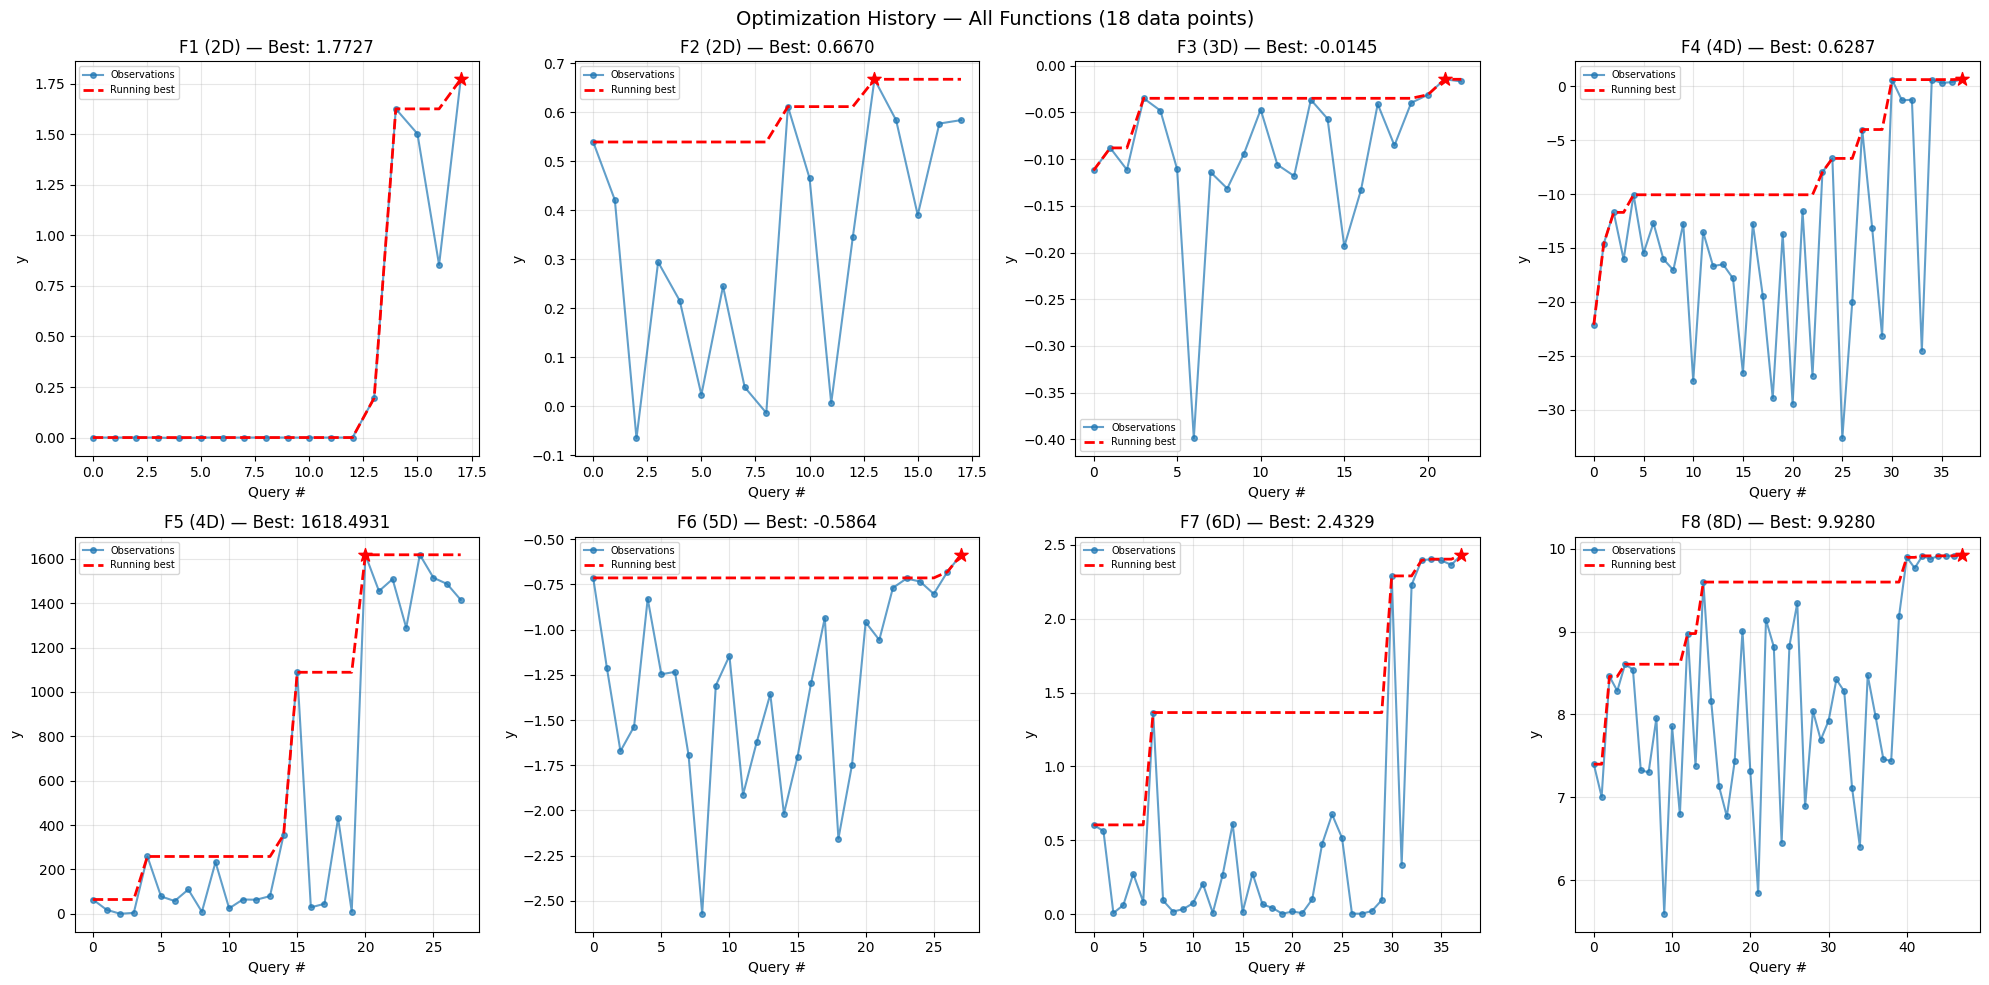

Saved optimization history plot.


In [62]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Optimization History — All Functions (18 data points)', fontsize=14)

for idx, func_id in enumerate(range(1, 9)):
    ax = axes[idx // 4, idx % 4]
    df = all_data[func_id]
    
    # Plot all observations
    y_vals = df['y'].values
    ax.plot(range(len(y_vals)), y_vals, 'o-', markersize=4, alpha=0.7, label='Observations')
    
    # Highlight running best
    running_best = np.maximum.accumulate(y_vals)
    ax.plot(range(len(y_vals)), running_best, 'r--', linewidth=2, label='Running best')
    
    # Highlight best point
    best_idx = np.argmax(y_vals)
    ax.scatter(best_idx, y_vals[best_idx], c='red', s=100, zorder=5, marker='*')
    
    ax.set_title(f'F{func_id} ({dims[func_id]}D) — Best: {best_values[func_id]:.4f}')
    ax.set_xlabel('Query #')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

import os
docs_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'docs')
os.makedirs(docs_dir, exist_ok=True)
plt.savefig(os.path.join(docs_dir, 'week9_optimization_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved optimization history plot.")

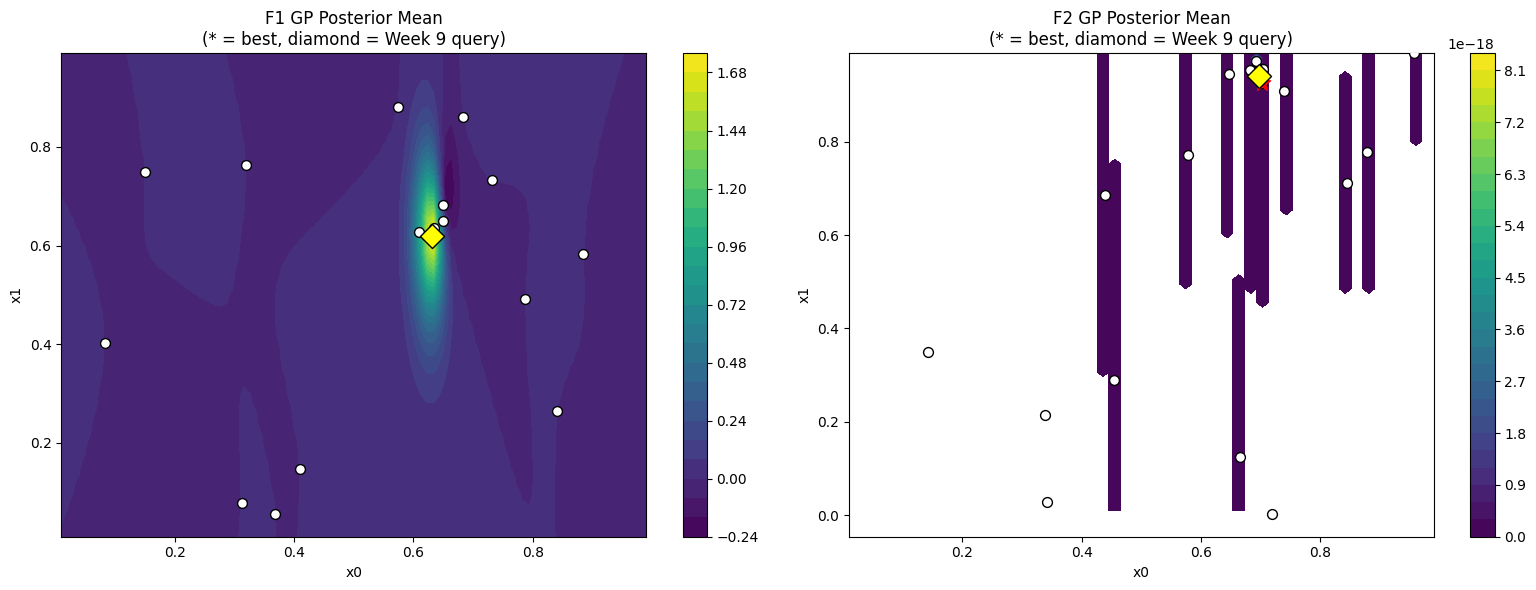

In [63]:
# GP landscape visualization for 2D functions (F1, F2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for plot_idx, func_id in enumerate([1, 2]):
    ax = axes[plot_idx]
    df = all_data[func_id]
    X = df[['x0', 'x1']].values
    y = df['y'].values
    
    # Fit a single GP for visualization
    kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=1.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)
    gp.fit(X, y)
    
    # Create grid
    x0_grid = np.linspace(0.01, 0.99, 100)
    x1_grid = np.linspace(0.01, 0.99, 100)
    X0, X1 = np.meshgrid(x0_grid, x1_grid)
    X_grid = np.column_stack([X0.ravel(), X1.ravel()])
    
    mu_grid = gp.predict(X_grid).reshape(100, 100)
    
    # Plot
    im = ax.contourf(X0, X1, mu_grid, levels=30, cmap='viridis')
    plt.colorbar(im, ax=ax)
    
    # Data points
    ax.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=50, zorder=5)
    
    # Best point
    best_idx = np.argmax(y)
    ax.scatter(X[best_idx, 0], X[best_idx, 1], c='red', s=150, marker='*', zorder=6)
    
    # Week 9 query
    q = week9_queries[func_id]
    ax.scatter(q[0], q[1], c='yellow', s=150, marker='D', zorder=6, edgecolors='black')
    
    ax.set_title(f'F{func_id} GP Posterior Mean\n(* = best, diamond = Week 9 query)')
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')

plt.tight_layout()

import os
docs_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'docs')
plt.savefig(os.path.join(docs_dir, 'week9_gp_landscape.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary and Submission

In [64]:
print("\n" + "=" * 70)
print("WEEK 9 (MODULE 20) — FINAL QUERIES")
print("=" * 70)

for func_id in range(1, 9):
    x = week9_queries[func_id]
    query_str = '-'.join([f"{v:.6f}" for v in x])
    current_best = best_values[func_id]
    print(f"\nF{func_id} ({dims[func_id]}D):")
    print(f"  Query: {query_str}")
    print(f"  Current best: {current_best:.6f}")


WEEK 9 (MODULE 20) — FINAL QUERIES

F1 (2D):
  Query: 0.630748-0.618965
  Current best: 1.772710

F2 (2D):
  Query: 0.696774-0.941425
  Current best: 0.666983

F3 (3D):
  Query: 0.529607-0.638966-0.389611
  Current best: -0.014466

F4 (4D):
  Query: 0.422458-0.396694-0.385944-0.406530
  Current best: 0.628683

F5 (4D):
  Query: 0.367932-0.276045-0.999957-0.999960
  Current best: 1618.493116

F6 (5D):
  Query: 0.652850-0.126519-0.771238-0.757384-0.031689
  Current best: -0.586391

F7 (6D):
  Query: 0.014132-0.131467-0.580441-0.217157-0.371219-0.747590
  Current best: 2.432916

F8 (8D):
  Query: 0.032640-0.087004-0.148791-0.058486-0.880818-0.342923-0.166261-0.227331
  Current best: 9.928049


In [65]:
# Save all submissions
for func_id in range(1, 9):
    x = week9_queries[func_id]
    query_str = '-'.join([f"{v:.6f}" for v in x])
    save_submission(func_id, query_str, module_name="Module 20 - Week 9")
    print(f"Saved F{func_id}: {query_str}")

Saved submission for Function 1 to submissions/submission_log.csv
Saved F1: 0.630748-0.618965
Saved submission for Function 2 to submissions/submission_log.csv
Saved F2: 0.696774-0.941425
Saved submission for Function 3 to submissions/submission_log.csv
Saved F3: 0.529607-0.638966-0.389611
Saved submission for Function 4 to submissions/submission_log.csv
Saved F4: 0.422458-0.396694-0.385944-0.406530
Saved submission for Function 5 to submissions/submission_log.csv
Saved F5: 0.367932-0.276045-0.999957-0.999960
Saved submission for Function 6 to submissions/submission_log.csv
Saved F6: 0.652850-0.126519-0.771238-0.757384-0.031689
Saved submission for Function 7 to submissions/submission_log.csv
Saved F7: 0.014132-0.131467-0.580441-0.217157-0.371219-0.747590
Saved submission for Function 8 to submissions/submission_log.csv
Saved F8: 0.032640-0.087004-0.148791-0.058486-0.880818-0.342923-0.166261-0.227331


## Part 2: Critical Reflection — Scaling, Emergence, and BBO

### Context

This week's analysis revealed that our previous optimization framework contained several systematic bugs that had been silently degrading performance for weeks. This reflection is grounded in the corrective process itself, not just the theory.

---

### 1. How do scaling laws influence your current query choices? Do you see diminishing returns or steady improvements?

Scaling laws appear in three distinct forms in our BBO challenge:

**Data scaling shows function-specific patterns, not universal trends.** The naive assumption would be that more data always helps. In practice:
- **F8 (8D, 48 points)**: Shows classic diminishing returns. Improvements went from +0.9 (W3) to +0.013 (W8). The GP is well-calibrated here (LOO-CV RMSE = 0.059) and the function landscape near the optimum is flat. More data in this region adds precision, not discovery.
- **F1 (2D, 18 points)**: Showed a **phase transition** — stuck at 1.626 for 3 weeks, then jumped to 1.773 when the GP finally had enough data to resolve the extremely narrow peak (width ~0.02). This mirrors emergent capability thresholds in neural scaling laws.
- **F4 (4D, 38 points)**: Despite having the most submissions (8), only 2 gave positive values. The positive region is so narrow that data scaling has mostly taught us where the function is NOT good. The breakthrough in W8 came from a qualitatively different search direction, not more data in the same region.

**Dimensional scaling directly determines strategy.** Our query budget is constant (1/week) while the search space grows as $10^d$. This creates a hard constraint:
- F1-F2 (2D): 18 points provide reasonable coverage. GP predictions are reliable enough for tight exploitation.
- F8 (8D): 48 points in $[0,1]^8$ is vanishingly sparse. We rely entirely on local structure exploitation because global exploration is impossible with our budget.
- This asymmetry is why we use function-specific radii (0.008 for F1, 0.010 for F8) rather than a uniform approach.

**Computational scaling matters for algorithm choice.** We switched from full-covariance Thompson Sampling ($O(N^3)$, caused OOM at 20K candidates) to diagonal approximation ($O(N)$). The theoretical loss from ignoring posterior correlations is small for candidate ranking, but the practical gain (the code actually runs) is decisive.

---

### 2. Where might emergent behaviours alter your expectations, and how are you preparing for them?

The most significant emergent behaviour we discovered this week was not in the optimization targets — it was in **our own optimization system**.

**Bug emergence through interaction.** The domain clipping bug (`np.clip(candidates, 0.01, 0.99)`) had been present since Week 1 but only became visible when we analysed why F5 could never beat its W1 result. The bug interacted with the `BoundaryAwareTrustRegion` in a particularly damaging way: the pinning step set x2/x3 to (0.993, 0.999), then the clip step immediately overrode them to 0.99. This is an emergent failure — neither component was obviously wrong in isolation, but their interaction produced systematic underperformance. In 7 of 8 submissions for F5, the bug cost 100-200 points.

**Similarly, the TS override interacted with acquisition function selection in unexpected ways.** The threshold `0.01 * |y_best|` was designed as a modest override, but for F3 (where y_best = -0.0145), the threshold became 0.000145 — essentially zero. Any trivial prediction difference triggered TS, which then selected exploratory points during what was supposed to be tight exploitation. This is an emergent behaviour of threshold-based rules: they behave differently across different scales.

**How we're preparing for future emergent issues:**
1. **Post-selection validation**: Checking that selected points are consistent with the intended strategy (e.g., directional queries should follow the improvement direction in all dimensions).
2. **Explicit comparison to known best**: Every query now shows its predicted delta from the current best. If the GP predicts regression, that's a red flag.
3. **Function-specific selection methods**: PI for exploitation, EI for exploration. No universal strategy.
4. **Removing automatic overrides**: The TS override has been eliminated entirely. Each selection method now does one thing clearly.

**Expected emergent behaviours going forward:**
- **F2**: With a tight exploit (r=0.015), we're testing a nearby point (x0=0.697, x1=0.941) that the GP rates as having ~10% probability of improvement. If the function is noisy, even this conservative perturbation may reveal variance structure that informs future strategies.
- **F7**: With x0 now allowed below 0.01, we may discover the function continues improving at x0→0. This could yield a significant gain that was impossible under the old clipping regime.
- **F5**: With x2/x3 now properly at ~1.0 AND x0/x1 held near the W1 optimum, we may discover whether the function has additional structure above x2=0.996.

---

### 3. What trade-offs between cost, robustness and performance are shaping your strategy now?

This week's experience has shifted our understanding of these trade-offs significantly.

**Robustness vs. performance is the dominant trade-off — and we were getting it wrong.** Our previous approach used EI (Expected Improvement) as the default acquisition function for exploitation strategies. EI rewards uncertainty, which means it systematically selects points further from the known best — exactly wrong for peaked functions. For F1, this produced a query predicted to be 0.075 below the current best. For F6, it reversed the improvement direction on x1.

The corrected approach uses PI (Probability of Improvement) for exploitation, which is fundamentally more conservative. PI asks "what is the probability this point beats the current best?" rather than "what is the expected gain?" This is the right question when downside risk (regression) is more costly than upside potential (marginal improvement).

**Concrete trade-offs by function:**

| Trade-off | Aggressive (EI/UCB) | Conservative (PI/Mean) | Our choice |
|-----------|---------------------|----------------------|------------|
| F1: peaked | Explores wider → almost certain regression | Stays near peak → low risk | **Conservative** (r=0.008, PI) |
| F2: stagnant/noisy | Explores widely → 8 consecutive failures | Tight local search → controlled risk | **Conservative** (r=0.015, PI) |
| F4: breakthrough | Explores around new best → may find better | Stays too close to W8 → misses nearby peak | **Moderate** (r=0.03, EI) |
| F5: boundary | Varies x0/x1 → loses 10+ points | Pins x0/x1 tight → preserves known optimum | **Ultra-conservative** (r=0.008) |
| F7: clipped optimum | Tests x0→0 → potential discovery | Stays at x0=0.01 → no new information | **Exploratory** (center at x0=0.005) |

**Cost trade-offs:**
- LOO-CV adds ~30% compute time but caught the TS override problem. Worth keeping.
- Diagonal Thompson Sampling loses correlation information but prevents OOM crashes. Essential.
- Smaller radii generate fewer diverse candidates but prevent catastrophic selections. The reduction from 20K candidates in [0.01, 0.99] to 20K in a tiny trust region actually increases local density, improving GP prediction quality.

---

### 4. How do you balance predictable optimisation with the risk of sudden but uneven emergent capabilities?

**The core lesson from this week: predictable optimization requires predictable tools.** Before we can balance exploitation with exploration, we need to ensure our exploitation actually works as intended. The bugs we found meant that our "exploitation" strategies were secretly performing exploration (due to TS overrides, too-large radii, and clipping errors).

**Our updated framework distinguishes three modes:**

1. **Locked functions** (F1, F5, F8): These have well-characterized optima with narrow peaks. The priority is *not losing what we have*. Strategies: tiny trust regions, PI selection, no TS. Risk tolerance: near zero.

2. **Trending functions** (F3, F4, F6): These show improvement trajectories that we want to ride. The priority is *following the trajectory faithfully* while allowing the GP to suggest minor corrections. Strategies: moderate trust regions centered on trajectory-predicted points, EI selection, direction validation.

3. **Stalled functions** (F2, F7): These need qualitatively new information. For F2, we use a tight exploit (r=0.015) since every previous exploration pushed x1 too high — the GP guides search in an untested direction. For F7, we test a genuinely new hypothesis (x0 < 0.01) enabled by the clipping fix.

**What makes this a "barbell strategy":**
- 5 functions (F1, F3, F5, F7, F8) use conservative approaches with near-zero regression risk
- 2 functions (F4, F6) take moderate directional bets
- 1 function (F2) makes a tight exploratory bet in an untested direction

**The meta-lesson about emergence:** The most dangerous emergent behaviour in our system was not in the black-box functions — it was in our own code. The interaction between clipping, TS overrides, and acquisition function selection created a system that behaved very differently from what we intended. This mirrors a broader principle in AI systems: emergence often manifests as unexpected interactions between components, not as novel behaviour in any single component.

**Roadmap for remaining weeks:**
- **Week 10**: Evaluate corrections. If F7 with low x0 improves, we have a new insight about boundary effects. If F2's tight exploit finds improvement, we know the function has nearby structure.
- **Week 11-12**: Progressively tighten exploitation. Shift any remaining exploration budget toward locking in gains.
- **Week 13 (Final)**: EXACT_RETURN on all 8 functions. Submit best known coordinates with maximum precision. Zero risk.